# Team members 

# Ahmad Alaa Abdelaziz Mahmoud & Mahmoud Mohamed El-sayed Saleh

In [43]:
import pandas as pd
import seaborn as sns

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset Info
 
### This data Source is Kaggle Website

https://www.kaggle.com/datasets/mustafakeser4/looker-ecommerce-bigquery-dataset?select=order_items.csv

In [3]:
df = pd.read_csv('C:/Users/ahmad/order_items.csv')

df.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,NaN,NaN,NaN,0.02
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,NaN,0.02
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,NaN,0.02
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,NaN,NaN,0.02
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,NaN,NaN,0.02


# Data Info 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181759 entries, 0 to 181758
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 181759 non-null  int64  
 1   order_id           181759 non-null  int64  
 2   user_id            181759 non-null  int64  
 3   product_id         181759 non-null  int64  
 4   inventory_item_id  181759 non-null  int64  
 5   status             181759 non-null  object 
 6   created_at         181759 non-null  object 
 7   shipped_at         118281 non-null  object 
 8   delivered_at       63841 non-null   object 
 9   returned_at        18232 non-null   object 
 10  sale_price         181759 non-null  float64
dtypes: float64(1), int64(5), object(5)
memory usage: 15.3+ MB


# Data Statistics

In [5]:
df.describe()

,id,order_id,user_id,product_id,inventory_item_id,sale_price
count,181759.000000,181759.000000,181759.000000,181759.000000,181759.000000,181759.000000
mean,90880.000000,62579.982609,49983.272020,15254.151838,245291.860007,59.568544
std,52469.448126,36125.987285,28830.895739,8413.482833,141661.912894,66.657262
min,1.000000,1.000000,1.000000,1.000000,3.000000,0.020000
25%,45440.500000,31266.500000,25031.500000,7979.500000,122565.000000,24.500000
50%,90880.000000,62529.000000,49983.000000,15966.000000,245284.000000,39.990002
75%,136319.500000,93845.500000,74867.500000,22504.000000,367983.000000,69.949997
max,181759.000000,125226.000000,100000.000000,29120.000000,490705.000000,999.000000


In [6]:
df.shape

(181759, 11)

In [7]:
df.columns


Index(['id', 'order_id', 'user_id', 'product_id', 'inventory_item_id',
       'status', 'created_at', 'shipped_at', 'delivered_at', 'returned_at',
       'sale_price'],
      dtype='object')

# Validating and Cleaning Data

In [8]:
df.dtypes

id                     int64
order_id               int64
user_id                int64
product_id             int64
inventory_item_id      int64
status                object
created_at            object
shipped_at            object
delivered_at          object
returned_at           object
sale_price           float64
dtype: object

#### First Step is to check for uniqueness of ID 

In [9]:
print(f"Number of Total Rows is: {df.shape[0]} \nnumber of Unique Transactions is :{df['id'].nunique()}")

Number of Total Rows is: 181759 
number of Unique Transactions is :181759


## The above cell shows that there is no duplicates in our data

### second step Checking repeated "order_id","user_id","product_id"

In [10]:
order_counts = df['order_id'].value_counts()

repeated_orders = order_counts[order_counts > 1]

print(f"Count of Repeated orders is : {repeated_orders.count()}")
print(repeated_orders.count)

Count of Repeated orders is : 37514
<bound method Series.count of order_id
551       4
70304     4
106023    4
106407    4
93518     4
         ..
572       2
56066     2
4194      2
108450    2
27413     2
Name: count, Length: 37514, dtype: int64>


In [11]:
users_counts = df['user_id'].value_counts()

repeated_users= users_counts[users_counts > 1]

print(f'Number of Repeated users is :{repeated_users.count()}')
print(repeated_users.count)

Number of Repeated users is :45048
<bound method Series.count of user_id
32996    14
80546    13
80952    13
46712    12
34249    12
         ..
9872      2
80667     2
89618     2
42835     2
81827     2
Name: count, Length: 45048, dtype: int64>


In [12]:
product_counts = df['product_id'].value_counts()

repeated_products = product_counts[product_counts > 1]

print(repeated_products)

product_id
18795    21
17045    19
21842    19
25209    18
27192    18
         ..
4992      2
14317     2
26253     2
10346     2
13010     2
Name: count, Length: 28644, dtype: int64


In [13]:
print("Total records:", len(df))
print("Unique orders:", df['order_id'].nunique())
print("Unique users:", df['user_id'].nunique())
print("Unique products:", df['product_id'].nunique())

Total records: 181759
Unique orders: 125226
Unique users: 80044
Unique products: 29046


In [14]:
summary = pd.DataFrame({
    'column': ['order_id', 'user_id', 'product_id'],
    'unique_values': [
        df['order_id'].nunique(),
        df['user_id'].nunique(),
        df['product_id'].nunique()
    ],
    'repeated_values': [
        df['order_id'].duplicated().sum(),
        df['user_id'].duplicated().sum(),
        df['product_id'].duplicated().sum()
    ]
})

summary

,column,unique_values,repeated_values
0,order_id,125226,56533
1,user_id,80044,101715
2,product_id,29046,152713


### Third step is converting Date columns from object to datetime

In [15]:
df[['created_at','shipped_at','delivered_at','returned_at']].dtypes

created_at      object
shipped_at      object
delivered_at    object
returned_at     object
dtype: object

In [16]:
date_cols = ['created_at', 'shipped_at', 'delivered_at', 'returned_at']

df[date_cols] = df[date_cols].apply(
    lambda col: pd.to_datetime(col, format='ISO8601')
)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181759 entries, 0 to 181758
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   id                 181759 non-null  int64              
 1   order_id           181759 non-null  int64              
 2   user_id            181759 non-null  int64              
 3   product_id         181759 non-null  int64              
 4   inventory_item_id  181759 non-null  int64              
 5   status             181759 non-null  object             
 6   created_at         181759 non-null  datetime64[ns, UTC]
 7   shipped_at         118281 non-null  datetime64[ns, UTC]
 8   delivered_at       63841 non-null   datetime64[ns, UTC]
 9   returned_at        18232 non-null   datetime64[ns, UTC]
 10  sale_price         181759 non-null  float64            
dtypes: datetime64[ns, UTC](4), float64(1), int64(5), object(1)
memory usage: 15.3+ MB


In [18]:
df.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,NaT,NaT,NaT,0.02
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,NaT,0.02
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,NaT,0.02
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,NaT,NaT,0.02
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,NaT,NaT,0.02


### Missing Values in dataset in %

In [19]:
df.isnull().sum()/df.shape[0] * 100

id                    0.000000
order_id              0.000000
user_id               0.000000
product_id            0.000000
inventory_item_id     0.000000
status                0.000000
created_at            0.000000
shipped_at           34.924268
delivered_at         64.876017
returned_at          89.969135
sale_price            0.000000
dtype: float64

# Explaination

however, the date-related columns contain a significant amount of missing data:

- shipped_at — 34.92% missing: Approximately one-third of the records do not have a shipping timestamp. This can occur when an item has not been shipped or when shipping information is unavailable.

- delivered_at — 64.88% missing: A large proportion of records have no delivery timestamp. These records may represent items that have not yet been delivered or for which delivery information is unavailable.

- returned_at — 89.97% missing: Most records do not have a return timestamp. This is expected if the majority of items were not returned; therefore, the missing values can be interpreted as no recorded return rather than automatically treating them as data errors.

In [20]:
df.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,NaT,NaT,NaT,0.02
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,NaT,0.02
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,NaT,0.02
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,NaT,NaT,0.02
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,NaT,NaT,0.02


## Status Validation

In [21]:
df['status'].unique()

array(['Cancelled', 'Complete', 'Shipped', 'Processing', 'Returned'],
      dtype=object)

## Here We are Checking the sequence of dates 'Created_at' must be Before 'shipped_at'

In [22]:
Check_date_Sequence = df[
    df['delivered_at'].notna() &
    df['created_at'].notna() &
    (df['delivered_at'] < df['created_at'])
]

Check_date_Sequence

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
36,104924,72282,57732,13659,283091,Complete,2023-04-18 01:05:54+00:00,2023-04-14 04:16:00+00:00,2023-04-14 13:04:00+00:00,NaT,1.82
37,122182,84145,67100,15332,329813,Complete,2023-10-08 12:48:46+00:00,2023-10-04 17:41:00+00:00,2023-10-07 21:58:00+00:00,NaT,1.82
71,16354,11304,9056,13606,44168,Complete,2022-12-25 09:46:43+00:00,2022-12-22 15:07:00+00:00,2022-12-23 18:10:00+00:00,NaT,2.50
80,33817,23311,18628,28913,91211,Returned,2021-12-31 03:33:39+00:00,2021-12-30 19:53:00+00:00,2021-12-30 20:38:00+00:00,2021-12-31 11:48:00+00:00,2.59
96,180370,124252,99237,28774,486997,Complete,2023-12-14 02:34:01+00:00,2023-12-12 03:14:00+00:00,2023-12-12 19:54:00+00:00,NaT,2.78
...,...,...,...,...,...,...,...,...,...,...,...
181532,150240,103468,82619,8300,405607,Returned,2023-10-04 11:32:32+00:00,2023-10-01 15:08:00+00:00,2023-10-01 21:03:00+00:00,2023-10-04 16:12:00+00:00,795.00
181548,159136,109584,87549,23803,429590,Complete,2021-09-02 09:21:30+00:00,2021-08-31 00:21:00+00:00,2021-09-02 03:24:00+00:00,NaT,815.00
181618,97182,66874,53432,18656,262211,Complete,2023-09-16 13:19:11+00:00,2023-09-15 07:04:00+00:00,2023-09-15 09:17:00+00:00,NaT,903.00
181742,159844,110086,87934,24110,431521,Complete,2024-01-14 08:55:04+00:00,2024-01-12 03:33:00+00:00,2024-01-13 01:47:00+00:00,NaT,990.00


# Phase 2 Features Engineering

### Creating more Date features like 'shipping_duration_days' ,'delivery_duration_days'

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181759 entries, 0 to 181758
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   id                 181759 non-null  int64              
 1   order_id           181759 non-null  int64              
 2   user_id            181759 non-null  int64              
 3   product_id         181759 non-null  int64              
 4   inventory_item_id  181759 non-null  int64              
 5   status             181759 non-null  object             
 6   created_at         181759 non-null  datetime64[ns, UTC]
 7   shipped_at         118281 non-null  datetime64[ns, UTC]
 8   delivered_at       63841 non-null   datetime64[ns, UTC]
 9   returned_at        18232 non-null   datetime64[ns, UTC]
 10  sale_price         181759 non-null  float64            
dtypes: datetime64[ns, UTC](4), float64(1), int64(5), object(1)
memory usage: 15.3+ MB


In [24]:
df['shipping_duration_days'] = (
    df['shipped_at'] - df['created_at']
).dt.days

df['delivery_duration_days'] = (
    df['delivered_at'] - df['shipped_at']
).dt.days


In [25]:
df.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,shipping_duration_days,delivery_duration_days
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,NaT,NaT,NaT,0.02,NaN,NaN
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,NaT,0.02,1.0,2.0
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,NaT,0.02,0.0,4.0
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,NaT,NaT,0.02,1.0,NaN
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,NaT,NaT,0.02,0.0,NaN


In [26]:
df.describe(include = "all")

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,shipping_duration_days,delivery_duration_days
count,181759.000000,181759.000000,181759.000000,181759.000000,181759.000000,181759,181759,118281,63841,18232,181759.000000,118281.000000,63841.000000
unique,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,Shipped,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,54440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,90880.000000,62579.982609,49983.272020,15254.151838,245291.860007,NaN,2022-10-24 17:46:02.968706816+00:00,2022-10-25 03:35:10.066188544+00:00,2022-10-27 23:47:53.183116032+00:00,2022-10-30 23:01:59.265073920+00:00,59.568544,0.039558,2.013784
min,1.000000,1.000000,1.000000,1.000000,3.000000,NaN,2019-01-06 02:25:41+00:00,2019-01-09 04:36:00+00:00,2019-01-18 04:47:00+00:00,2019-01-21 03:46:00+00:00,0.020000,-4.000000,0.000000
25%,45440.500000,31266.500000,25031.500000,7979.500000,122565.000000,NaN,2022-02-24 10:16:22+00:00,2022-02-25 15:28:00+00:00,2022-02-28 12:39:00+00:00,2022-02-28 08:49:15+00:00,24.500000,-1.000000,1.000000
50%,90880.000000,62529.000000,49983.000000,15966.000000,245284.000000,NaN,2023-02-21 01:19:27+00:00,2023-02-21 03:39:00+00:00,2023-02-24 23:08:00+00:00,2023-03-03 05:18:00+00:00,39.990002,0.000000,2.000000
75%,136319.500000,93845.500000,74867.500000,22504.000000,367983.000000,NaN,2023-09-27 03:51:44.500000+00:00,2023-09-27 19:19:00+00:00,2023-09-30 04:30:00+00:00,2023-10-03 20:22:15+00:00,69.949997,1.000000,3.000000
max,181759.000000,125226.000000,100000.000000,29120.000000,490705.000000,NaN,2024-01-21 18:02:23.533893+00:00,2024-01-20 17:57:00+00:00,2024-01-24 22:14:42.220676+00:00,2024-01-27 05:16:19.046968+00:00,999.000000,3.000000,4.000000


# Now Data is cleaned 
## now i will join 'order_items' table with 'user' and 'products' to answer our question and get insights

In [27]:
df_p = pd.read_csv('C:/Users/ahmad/products.csv')
df_u = pd.read_csv('C:/Users/ahmad/users.csv')
df_u.head()

,id,first_name,last_name,email,age,gender,state,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at
0,457,Timothy,Bush,timothybush@example.net,65,M,Acre,87620 Johnson Hills,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2022-07-19 13:51:00+00:00
1,6578,Elizabeth,Martinez,elizabethmartinez@example.com,34,F,Acre,1705 Nielsen Land,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2023-11-08 18:49:00+00:00
2,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Email,2019-08-24 06:10:00+00:00
3,60193,Jimmy,Conner,jimmyconner@example.com,64,M,Acre,0966 Jose Branch Apt. 008,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2020-02-15 11:26:00+00:00
4,64231,Natasha,Wilson,natashawilson@example.net,25,F,Acre,20798 Phillip Trail Apt. 392,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2020-03-13 06:45:00+00:00


In [28]:
df_u['Name'] = df_u['first_name'] + ' ' + df_u['last_name']

In [29]:
df_u.head()

,id,first_name,last_name,email,age,gender,state,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at,Name
0,457,Timothy,Bush,timothybush@example.net,65,M,Acre,87620 Johnson Hills,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2022-07-19 13:51:00+00:00,Timothy Bush
1,6578,Elizabeth,Martinez,elizabethmartinez@example.com,34,F,Acre,1705 Nielsen Land,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2023-11-08 18:49:00+00:00,Elizabeth Martinez
2,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Email,2019-08-24 06:10:00+00:00,Christopher Mendoza
3,60193,Jimmy,Conner,jimmyconner@example.com,64,M,Acre,0966 Jose Branch Apt. 008,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2020-02-15 11:26:00+00:00,Jimmy Conner
4,64231,Natasha,Wilson,natashawilson@example.net,25,F,Acre,20798 Phillip Trail Apt. 392,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2020-03-13 06:45:00+00:00,Natasha Wilson


In [30]:
df_u.country.value_counts()

country
China             34150
United States     22522
Brasil            14507
South Korea        5316
France             4700
United Kingdom     4561
Germany            4155
Spain              4062
Japan              2438
Australia          2146
Belgium            1185
Poland              235
Colombia             17
Deutschland           2
España                2
Austria               2
Name: count, dtype: int64

In [31]:
df_order_prod = pd.merge(
                df,
                df_p[['id','category','name','brand','department']],
                left_on= 'product_id',
                right_on = 'id',
                how = 'inner'
)
df_order_prod.head()

,id_x,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,shipping_duration_days,delivery_duration_days,id_y,category,name,brand,department
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,NaT,NaT,NaT,0.02,NaN,NaN,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,NaT,0.02,1.0,2.0,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,NaT,0.02,0.0,4.0,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,NaT,NaT,0.02,1.0,NaN,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,NaT,NaT,0.02,0.0,NaN,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women


In [32]:
df_order_prod_user = pd.merge(
                            df_order_prod,
                            df_u [['id','Name','gender','age','country']],
                            left_on='user_id',
                            right_on = 'id',
                            how = 'inner'
)
df_order_prod_user

,id_x,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,...,id_y,category,name,brand,department,id,Name,gender,age,country
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,NaT,NaT,NaT,...,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,83582,Kathryn Ortega,F,29,China
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,NaT,...,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,22551,Terri Alvarez,F,35,China
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,NaT,...,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,28215,Rebecca Mcgee,F,49,United States
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,NaT,NaT,...,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,20165,Shelly Rogers,F,44,Japan
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,NaT,NaT,...,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,71954,Mariah Stephens,F,59,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181754,9674,6679,5325,24447,26095,Returned,2020-12-23 00:05:01+00:00,2020-12-25 22:54:00+00:00,2020-12-28 07:08:00+00:00,2020-12-30 22:43:00+00:00,...,24447,Outerwear & Coats,Darla,Alpha Industries,Men,5325,Joseph Carpenter,M,23,China
181755,7801,5416,4283,24447,21078,Shipped,2022-01-12 23:51:07+00:00,2022-01-10 03:42:00+00:00,NaT,NaT,...,24447,Outerwear & Coats,Darla,Alpha Industries,Men,4283,Adam Vasquez,M,55,South Korea
181756,62986,43364,34691,23546,169937,Shipped,2023-02-26 00:38:43+00:00,2023-02-25 06:53:00+00:00,NaT,NaT,...,23546,Shorts,Alpha Industries Rip Stop Short,Alpha Industries,Men,34691,Kenneth Ramirez,M,58,South Korea
181757,106577,73418,58623,24447,287560,Shipped,2023-11-12 02:41:02+00:00,2023-11-14 20:44:00+00:00,NaT,NaT,...,24447,Outerwear & Coats,Darla,Alpha Industries,Men,58623,Jon Medina,M,60,United Kingdom


In [33]:
df_cleaned = df_order_prod_user
df_cleaned

,id_x,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,...,id_y,category,name,brand,department,id,Name,gender,age,country
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,NaT,NaT,NaT,...,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,83582,Kathryn Ortega,F,29,China
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,NaT,...,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,22551,Terri Alvarez,F,35,China
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,NaT,...,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,28215,Rebecca Mcgee,F,49,United States
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,NaT,NaT,...,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,20165,Shelly Rogers,F,44,Japan
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,NaT,NaT,...,14235,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,71954,Mariah Stephens,F,59,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181754,9674,6679,5325,24447,26095,Returned,2020-12-23 00:05:01+00:00,2020-12-25 22:54:00+00:00,2020-12-28 07:08:00+00:00,2020-12-30 22:43:00+00:00,...,24447,Outerwear & Coats,Darla,Alpha Industries,Men,5325,Joseph Carpenter,M,23,China
181755,7801,5416,4283,24447,21078,Shipped,2022-01-12 23:51:07+00:00,2022-01-10 03:42:00+00:00,NaT,NaT,...,24447,Outerwear & Coats,Darla,Alpha Industries,Men,4283,Adam Vasquez,M,55,South Korea
181756,62986,43364,34691,23546,169937,Shipped,2023-02-26 00:38:43+00:00,2023-02-25 06:53:00+00:00,NaT,NaT,...,23546,Shorts,Alpha Industries Rip Stop Short,Alpha Industries,Men,34691,Kenneth Ramirez,M,58,South Korea
181757,106577,73418,58623,24447,287560,Shipped,2023-11-12 02:41:02+00:00,2023-11-14 20:44:00+00:00,NaT,NaT,...,24447,Outerwear & Coats,Darla,Alpha Industries,Men,58623,Jon Medina,M,60,United Kingdom


In [34]:
df_cleaned.columns

Index(['id_x', 'order_id', 'user_id', 'product_id', 'inventory_item_id',
       'status', 'created_at', 'shipped_at', 'delivered_at', 'returned_at',
       'sale_price', 'shipping_duration_days', 'delivery_duration_days',
       'id_y', 'category', 'name', 'brand', 'department', 'id', 'Name',
       'gender', 'age', 'country'],
      dtype='object')

In [35]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181759 entries, 0 to 181758
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   id_x                    181759 non-null  int64              
 1   order_id                181759 non-null  int64              
 2   user_id                 181759 non-null  int64              
 3   product_id              181759 non-null  int64              
 4   inventory_item_id       181759 non-null  int64              
 5   status                  181759 non-null  object             
 6   created_at              181759 non-null  datetime64[ns, UTC]
 7   shipped_at              118281 non-null  datetime64[ns, UTC]
 8   delivered_at            63841 non-null   datetime64[ns, UTC]
 9   returned_at             18232 non-null   datetime64[ns, UTC]
 10  sale_price              181759 non-null  float64            
 11  shipping_duration_days  11

In [36]:
df_cleaned.describe()

,id_x,order_id,user_id,product_id,inventory_item_id,sale_price,shipping_duration_days,delivery_duration_days,id_y,id,age
count,181759.000000,181759.000000,181759.000000,181759.000000,181759.000000,181759.000000,118281.000000,63841.000000,181759.000000,181759.000000,181759.000000
mean,90880.000000,62579.982609,49983.272020,15254.151838,245291.860007,59.568544,0.039558,2.013784,15254.151838,49983.272020,41.063749
std,52469.448126,36125.987285,28830.895739,8413.482833,141661.912894,66.657262,1.658796,1.417355,8413.482833,28830.895739,17.032648
min,1.000000,1.000000,1.000000,1.000000,3.000000,0.020000,-4.000000,0.000000,1.000000,1.000000,12.000000
25%,45440.500000,31266.500000,25031.500000,7979.500000,122565.000000,24.500000,-1.000000,1.000000,7979.500000,25031.500000,26.000000
50%,90880.000000,62529.000000,49983.000000,15966.000000,245284.000000,39.990002,0.000000,2.000000,15966.000000,49983.000000,41.000000
75%,136319.500000,93845.500000,74867.500000,22504.000000,367983.000000,69.949997,1.000000,3.000000,22504.000000,74867.500000,56.000000
max,181759.000000,125226.000000,100000.000000,29120.000000,490705.000000,999.000000,3.000000,4.000000,29120.000000,100000.000000,70.000000


In [37]:
df_cleaned.drop(columns=['id','id_x','id_y','inventory_item_id'],inplace=True)

In [38]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181759 entries, 0 to 181758
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   order_id                181759 non-null  int64              
 1   user_id                 181759 non-null  int64              
 2   product_id              181759 non-null  int64              
 3   status                  181759 non-null  object             
 4   created_at              181759 non-null  datetime64[ns, UTC]
 5   shipped_at              118281 non-null  datetime64[ns, UTC]
 6   delivered_at            63841 non-null   datetime64[ns, UTC]
 7   returned_at             18232 non-null   datetime64[ns, UTC]
 8   sale_price              181759 non-null  float64            
 9   shipping_duration_days  118281 non-null  float64            
 10  delivery_duration_days  63841 non-null   float64            
 11  category                18

In [39]:
df_cleaned.rename(
    columns={
        'category': 'prod_category',
        'Name': 'customer_name',
        'name': 'prod_name'
    },
    inplace=True
)

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181759 entries, 0 to 181758
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   order_id                181759 non-null  int64              
 1   user_id                 181759 non-null  int64              
 2   product_id              181759 non-null  int64              
 3   status                  181759 non-null  object             
 4   created_at              181759 non-null  datetime64[ns, UTC]
 5   shipped_at              118281 non-null  datetime64[ns, UTC]
 6   delivered_at            63841 non-null   datetime64[ns, UTC]
 7   returned_at             18232 non-null   datetime64[ns, UTC]
 8   sale_price              181759 non-null  float64            
 9   shipping_duration_days  118281 non-null  float64            
 10  delivery_duration_days  63841 non-null   float64            
 11  prod_category           18

In [40]:
df_cleaned.head()

,order_id,user_id,product_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,shipping_duration_days,delivery_duration_days,prod_category,prod_name,brand,department,customer_name,gender,age,country
0,104663,83582,14235,Cancelled,2023-05-07 06:08:40+00:00,NaT,NaT,NaT,0.02,NaN,NaN,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,Kathryn Ortega,F,29,China
1,28204,22551,14235,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,NaT,0.02,1.0,2.0,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,Terri Alvarez,F,35,China
2,35223,28215,14235,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,NaT,0.02,0.0,4.0,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,Rebecca Mcgee,F,49,United States
3,25278,20165,14235,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,NaT,NaT,0.02,1.0,NaN,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,Shelly Rogers,F,44,Japan
4,90241,71954,14235,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,NaT,NaT,0.02,0.0,NaN,Accessories,Indestructable Aluminum Aluma Wallet - RED,marshal,Women,Mariah Stephens,F,59,United Kingdom


In [41]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181759 entries, 0 to 181758
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   order_id                181759 non-null  int64              
 1   user_id                 181759 non-null  int64              
 2   product_id              181759 non-null  int64              
 3   status                  181759 non-null  object             
 4   created_at              181759 non-null  datetime64[ns, UTC]
 5   shipped_at              118281 non-null  datetime64[ns, UTC]
 6   delivered_at            63841 non-null   datetime64[ns, UTC]
 7   returned_at             18232 non-null   datetime64[ns, UTC]
 8   sale_price              181759 non-null  float64            
 9   shipping_duration_days  118281 non-null  float64            
 10  delivery_duration_days  63841 non-null   float64            
 11  prod_category           18

# let's answer some questions

### 1- What statuses are most common?

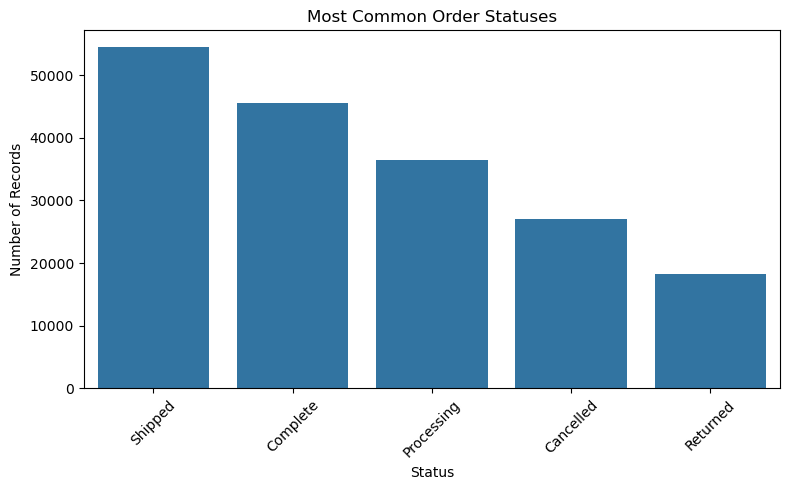

In [44]:

status_counts = df_cleaned['status'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)

plt.title('Most Common Order Statuses')
plt.xlabel('Status')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Which products generate the highest sales value?

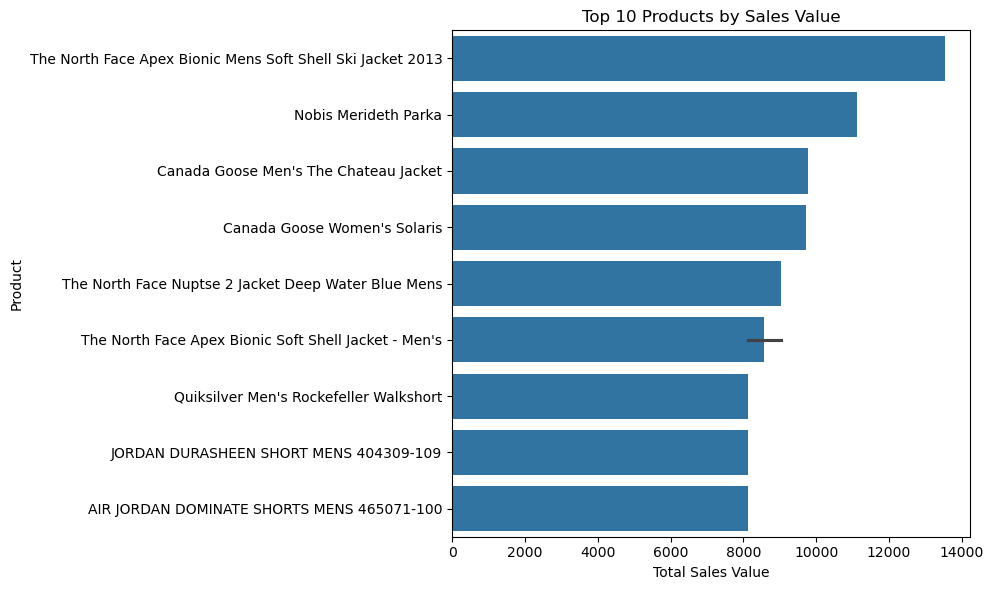

In [45]:
top_products = (
    df_cleaned
    .groupby(['product_id', 'prod_name'], dropna=False)['sale_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_products,
    x='sale_price',
    y='prod_name'
)

plt.title('Top 10 Products by Sales Value')
plt.xlabel('Total Sales Value')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

### 3. Which orders generate the highest sales value?

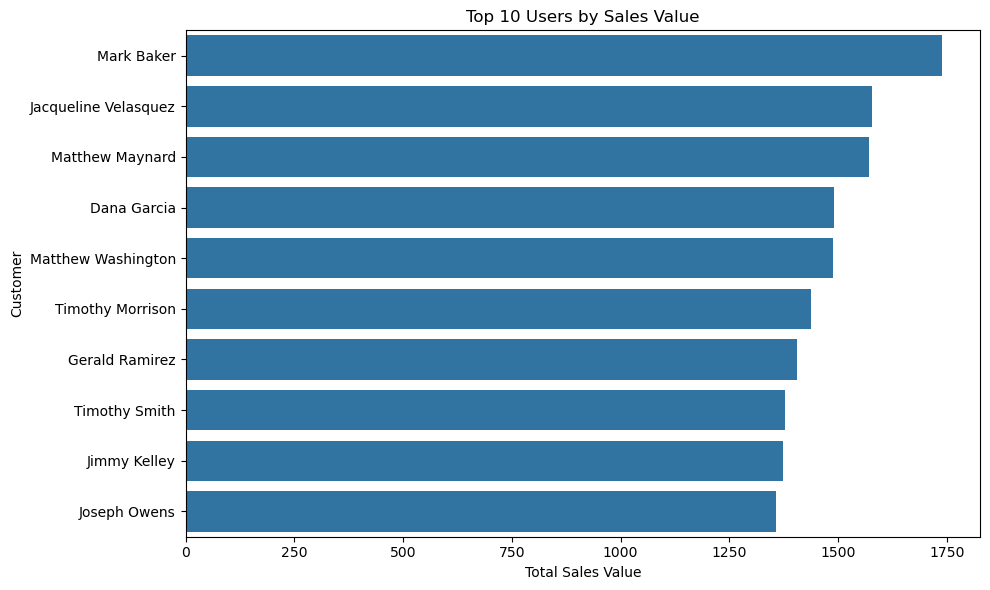

In [47]:
top_users = (
    df_cleaned
    .groupby(['user_id', 'customer_name'], dropna=False)['sale_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_users,
    x='sale_price',
    y='customer_name'
)

plt.title('Top 10 Users by Sales Value')
plt.xlabel('Total Sales Value')
plt.ylabel('Customer')
plt.tight_layout()
plt.show()

### 4. What is the average delivery time?

In [48]:
avg_delivery = df_cleaned['delivery_duration_days'].mean()

print(f"Average delivery time: {avg_delivery:.2f} days")

Average delivery time: 2.01 days


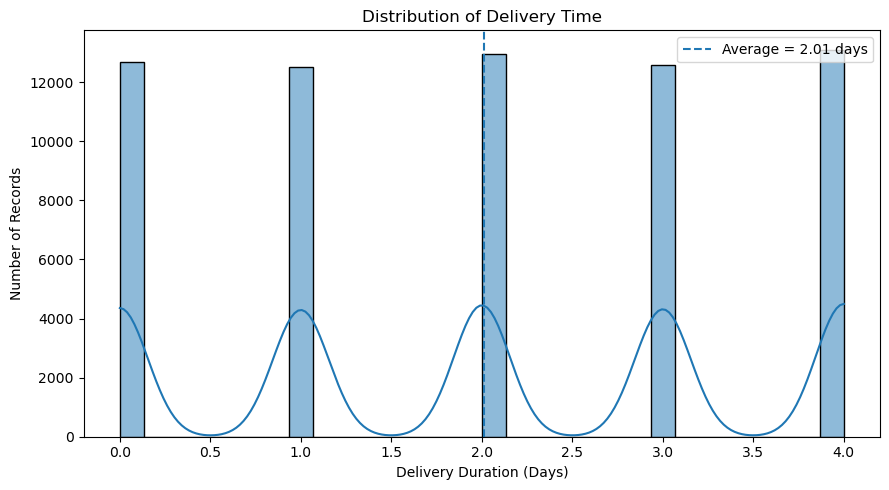

In [49]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_cleaned,
    x='delivery_duration_days',
    bins=30,
    kde=True
)

plt.axvline(
    avg_delivery,
    linestyle='--',
    label=f'Average = {avg_delivery:.2f} days'
)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Duration (Days)')
plt.ylabel('Number of Records')
plt.legend()
plt.tight_layout()
plt.show()

### 5. What percentage of records are returned?

In [50]:
return_percentage = (
    df_cleaned['returned_at'].notna().mean() * 100
)

print(f"Returned records: {return_percentage:.2f}%")

Returned records: 10.03%


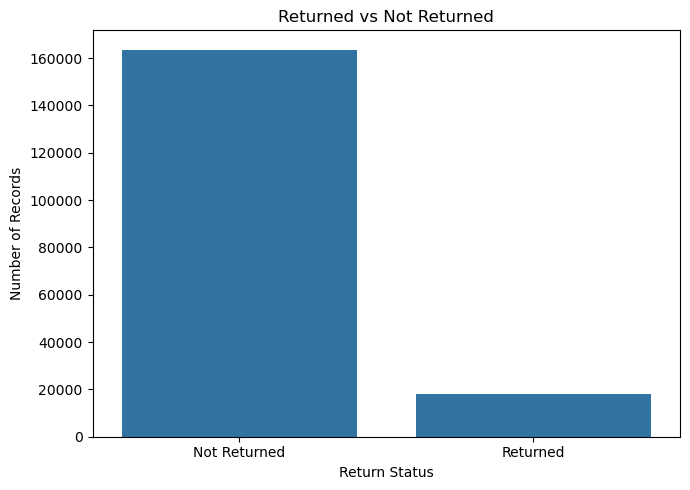

In [51]:
return_status = (
    df_cleaned['returned_at']
    .notna()
    .map({True: 'Returned', False: 'Not Returned'})
    .value_counts()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=return_status.index,
    y=return_status.values
)

plt.title('Returned vs Not Returned')
plt.xlabel('Return Status')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

### 6-Which time periods have the highest sales value?

C:\Users\ahmad\AppData\Local\Temp\ipykernel_25896\501689346.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=df_cleaned['created_at'].dt.to_period('M'))


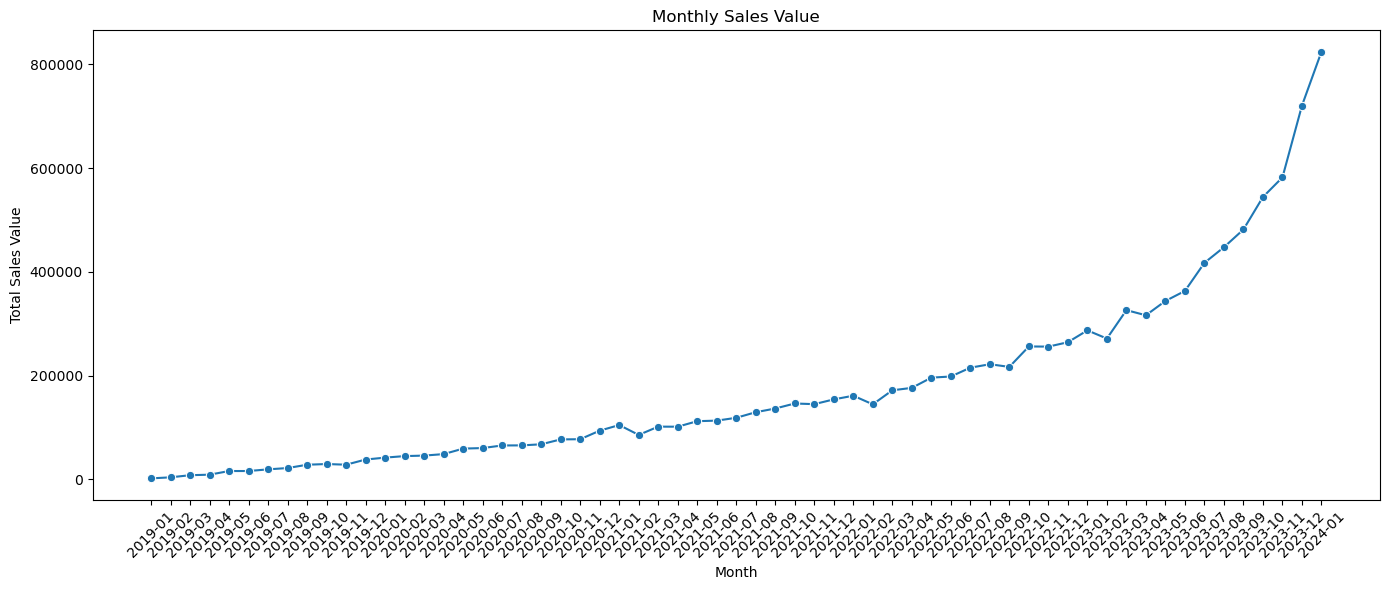

In [53]:
monthly_sales = (
    df_cleaned
    .assign(month=df_cleaned['created_at'].dt.to_period('M'))
    .groupby('month')['sale_price']
    .sum()
    .reset_index()
)

monthly_sales['month'] = monthly_sales['month'].astype(str)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x='month',
    y='sale_price',
    marker='o'
)

plt.title('Monthly Sales Value')
plt.xlabel('Month')
plt.ylabel('Total Sales Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();

### 7. How many records have invalid date sequences?

In [54]:
invalid_created_shipped = (
    df_cleaned['shipped_at'].notna() &
    (df_cleaned['shipped_at'] < df_cleaned['created_at'])
)

invalid_shipped_delivered = (
    df_cleaned['shipped_at'].notna() &
    df_cleaned['delivered_at'].notna() &
    (df_cleaned['delivered_at'] < df_cleaned['shipped_at'])
)

invalid_created_delivered = (
    df_cleaned['delivered_at'].notna() &
    (df_cleaned['delivered_at'] < df_cleaned['created_at'])
)

invalid_return = (
    df_cleaned['returned_at'].notna() &
    (df_cleaned['returned_at'] < df_cleaned['created_at'])
)

invalid_any = (
    invalid_created_shipped |
    invalid_shipped_delivered |
    invalid_created_delivered |
    invalid_return
)

invalid_count = invalid_any.sum()

print(f"Invalid date sequence records: {invalid_count}")

Invalid date sequence records: 35872


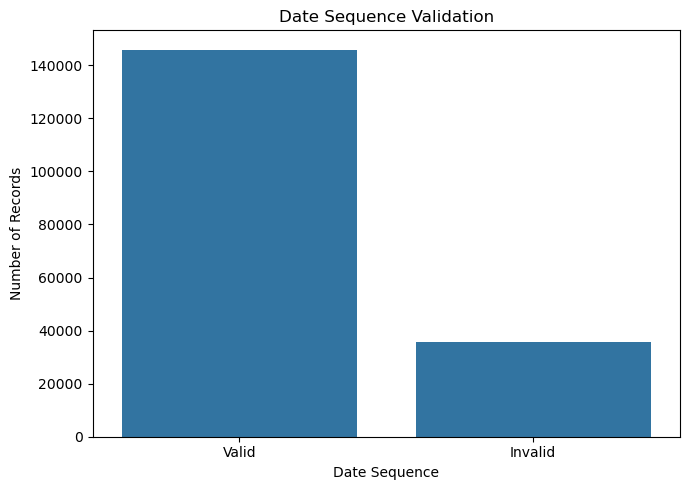

In [55]:
date_quality = pd.Series({
    'Valid': (~invalid_any).sum(),
    'Invalid': invalid_any.sum()
})

plt.figure(figsize=(7, 5))

sns.barplot(
    x=date_quality.index,
    y=date_quality.values
)

plt.title('Date Sequence Validation')
plt.xlabel('Date Sequence')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

### AGE ditro

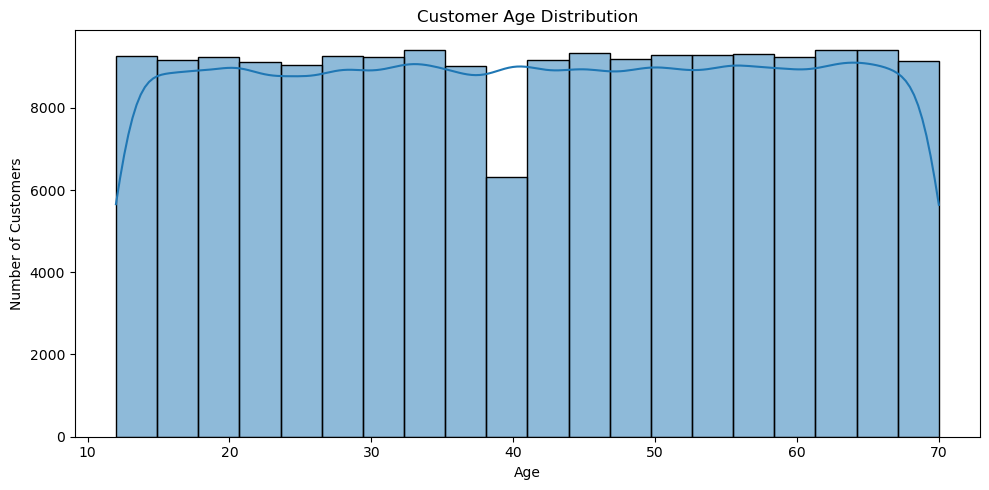

In [56]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_cleaned,
    x='age',
    bins=20,
    kde=True
)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Sales Value by Age

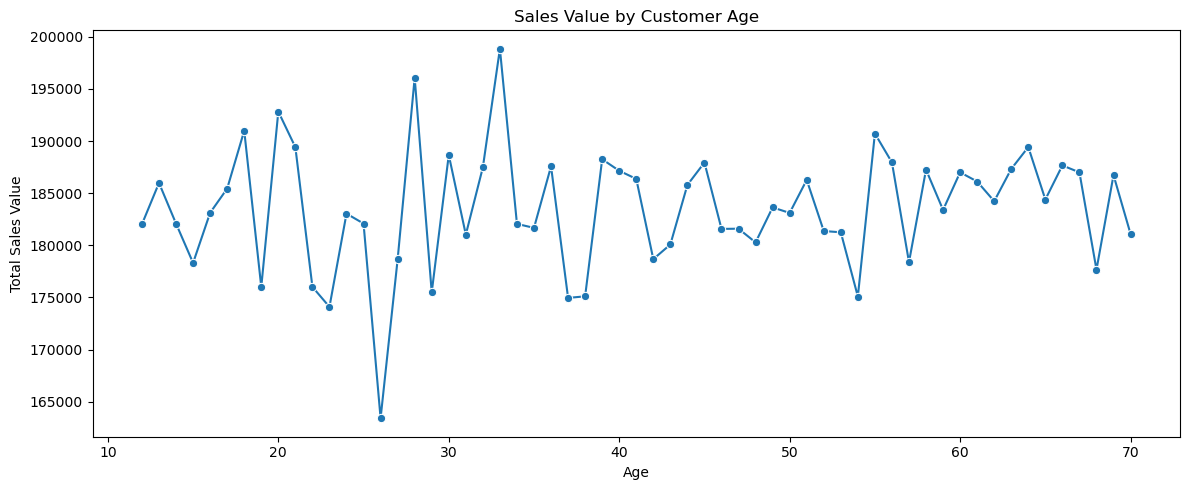

In [57]:
age_sales = (
    df_cleaned
    .groupby('age')['sale_price']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=age_sales,
    x='age',
    y='sale_price',
    marker='o'
)

plt.title('Sales Value by Customer Age')
plt.xlabel('Age')
plt.ylabel('Total Sales Value')
plt.tight_layout()
plt.show()

### Top Countries by Number of Records

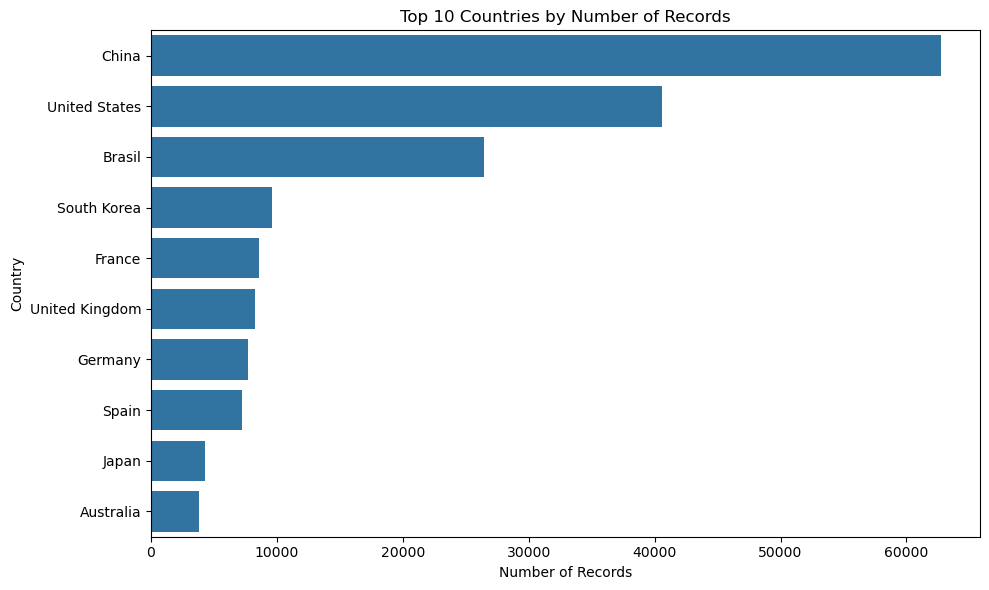

In [58]:
top_countries = (
    df_cleaned['country']
    .value_counts()
    .head(10)
    .reset_index()
)

top_countries.columns = ['country', 'count']

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_countries,
    x='count',
    y='country'
)

plt.title('Top 10 Countries by Number of Records')
plt.xlabel('Number of Records')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Top Countries by Sales Value

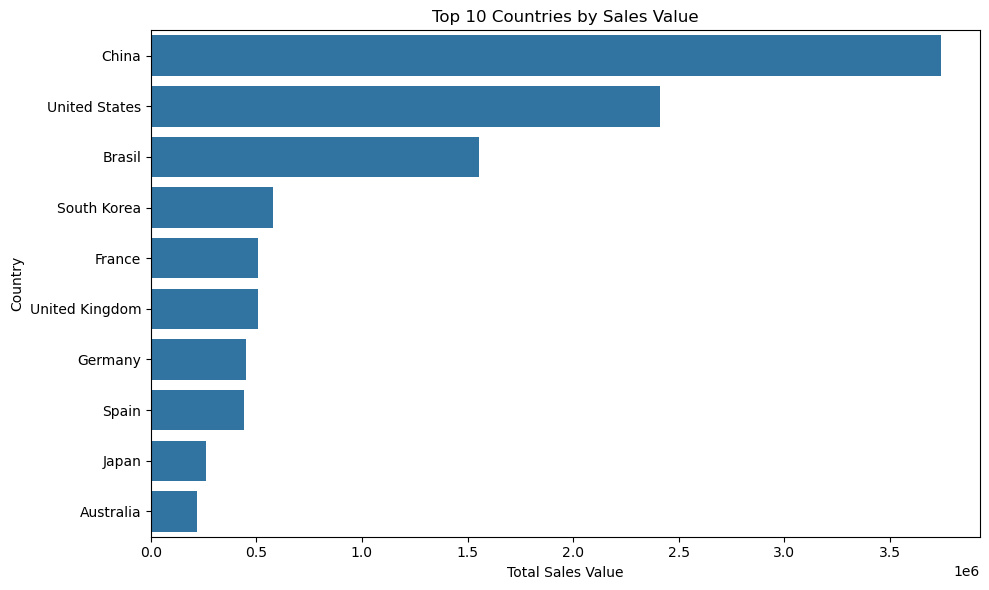

In [59]:
country_sales = (
    df_cleaned
    .groupby('country')['sale_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=country_sales,
    x='sale_price',
    y='country'
)

plt.title('Top 10 Countries by Sales Value')
plt.xlabel('Total Sales Value')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Sales Value by Product Category

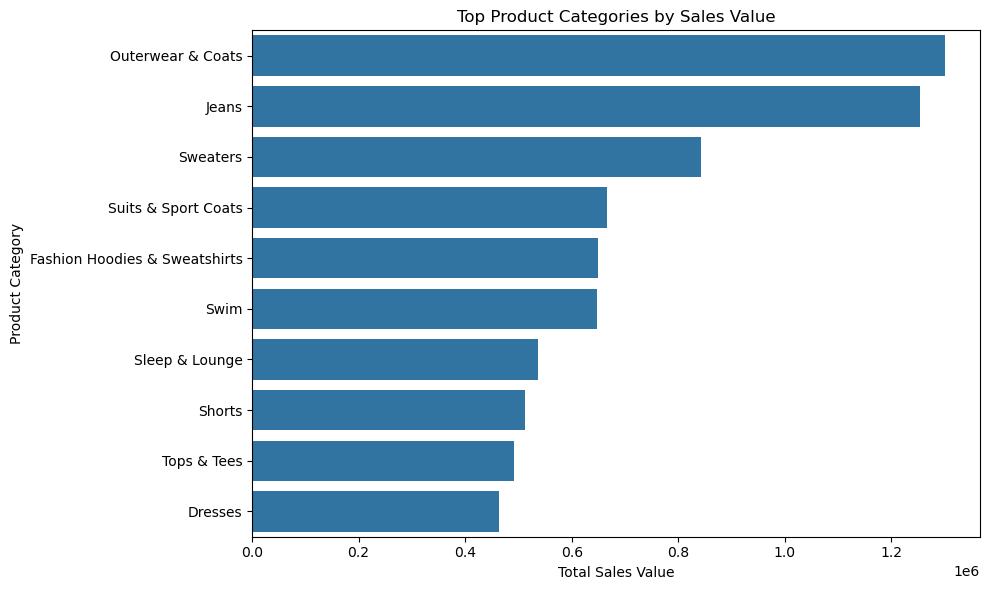

In [60]:
category_sales = (
    df_cleaned
    .groupby('prod_category')['sale_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_sales,
    x='sale_price',
    y='prod_category'
)

plt.title('Top Product Categories by Sales Value')
plt.xlabel('Total Sales Value')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()